In [12]:
import numpy as np
import pandas as pd

In [13]:
# Define random seed
seed = 22

In [14]:
def sample_geospatial_data(input_csv, output_csv, n_lat_bins=20, n_lon_bins=40, lat_name='latitude', lon_name='longitude', seed=None):
    """
    Sample all points from a CSV to maximize usage while keeping roughly uniform spatial distribution.

    Parameters:
    - input_csv: Path to CSV with latitude and longitude columns
    - output_csv: Path to save sampled CSV
    - n_lat_bins: Number of latitude bins (equal-area)
    - n_lon_bins: Number of longitude bins per latitude band
    - lat_name: Name of latitude column in CSV
    - lon_name: Name of longitude column in CSV
    - seed: Optional random seed

    Returns:
    - sampled_df: Pandas DataFrame of sampled points
    """
    if seed is not None:
        np.random.seed(seed)

    # Load CSV
    df = pd.read_csv(input_csv, skiprows=1)
    if lat_name not in df.columns or lon_name not in df.columns:
        raise ValueError("CSV must contain 'latitude' and 'longitude' columns")

    # Latitude edges (equal-area)
    lat_edges = np.arcsin(np.linspace(-1, 1, n_lat_bins + 1)) * 180 / np.pi

    sampled_rows = []
    for i in range(n_lat_bins):
        lat_min = lat_edges[i]
        lat_max = lat_edges[i + 1]
        df_lat_band = df[(df[lat_name] >= lat_min) & (df[lat_name] < lat_max)]
        if df_lat_band.empty:
            continue

        # Longitude bins (uniform)
        lon_edges = np.linspace(-180, 180, n_lon_bins + 1)
        for j in range(n_lon_bins):
            lon_min = lon_edges[j]
            lon_max = lon_edges[j + 1]
            df_bin = df_lat_band[(df_lat_band[lon_name] >= lon_min) & (df_lat_band[lon_name] < lon_max)]
            if df_bin.empty:
                continue

            # Take all points in this bin
            sampled_rows.append(df_bin)

    # Combine sampled points
    if sampled_rows:
        sampled_df = pd.concat(sampled_rows).reset_index(drop=True)
    else:
        sampled_df = pd.DataFrame(columns=df.columns)

    # Save to CSV
    sampled_df.to_csv(output_csv, index=False)
    print(f"Saved {len(sampled_df)} points to '{output_csv}'")

    return sampled_df


In [15]:
# Example usage
sampled_df = sample_geospatial_data("../WMA_fractions_v2.csv", "../sampled_data1.csv", n_lat_bins=20, n_lon_bins=20,lat_name='Latitude_[deg_N]', lon_name='Longitude_[deg_E]', seed=seed)
print(sampled_df.head())

Saved 11402848 points to '../sampled_data1.csv'
   Arctic_Surface_Water_[fraction]  Modified_summer_Pacific_Water_[fraction]  \
0                         0.000000                                  0.000000   
1                         0.000000                                  0.000000   
2                         0.025087                                  0.060607   
3                         0.036735                                  0.063328   
4                         0.061175                                  0.075753   

   Summer_Pacific_Water_[fraction]  Winter_Pacific_Water_[fraction]  \
0                         0.438782                         0.000000   
1                         0.472680                         0.000000   
2                         0.318273                         0.186830   
3                         0.271317                         0.070358   
4                         0.114151                         0.063142   

   Norwegian_Current_Water_[fraction]  Atlan

In [6]:
def sample_geospatial_data(input_csv, output_csv, n_lat_bins=20, n_lon_bins=40, lat_name='latitude', lon_name='longitude'):
    """
    Vectorized spatial sampling from a CSV to maximize usage while maintaining roughly uniform distribution.

    Parameters:
    - input_csv: CSV with latitude and longitude columns
    - output_csv: CSV to save sampled points
    - n_lat_bins: Number of latitude bins (equal-area)
    - n_lon_bins: Number of longitude bins
    - lat_name: Name of latitude column in CSV
    - lon_name: Name of longitude column in CSV

    Returns:
    - sampled_df: Pandas DataFrame with sampled points
    """
    # Load CSV
    df = pd.read_csv(input_csv, skiprows=1)
    
    if lat_name not in df.columns or lon_name not in df.columns:
        raise ValueError("CSV must contain "+lat_name+" and "+lon_name+" columns")

    # Latitude edges (equal-area)
    lat_edges = np.arcsin(np.linspace(-1, 1, n_lat_bins + 1)) * 180 / np.pi
    lon_edges = np.linspace(-180, 180, n_lon_bins + 1)

    # Assign bin indices to all points
    lat_bin_indices = np.digitize(df[lat_name], lat_edges) - 1
    lon_bin_indices = np.digitize(df[lon_name], lon_edges) - 1

    # Filter out-of-range indices (digitize can assign len(edges) if exactly max)
    valid_mask = (lat_bin_indices >= 0) & (lat_bin_indices < n_lat_bins) & \
                 (lon_bin_indices >= 0) & (lon_bin_indices < n_lon_bins)
    df = df[valid_mask].copy()
    lat_bin_indices = lat_bin_indices[valid_mask]
    lon_bin_indices = lon_bin_indices[valid_mask]

    # Create a combined bin index for grouping
    df['bin_index'] = lat_bin_indices * n_lon_bins + lon_bin_indices

    # Group by bin_index and collect all points per bin
    grouped = df.groupby('bin_index', sort=False)
    sampled_df = grouped.apply(lambda g: g).reset_index(drop=True)

    # Drop helper column
    sampled_df = sampled_df.drop(columns='bin_index')

    # Save to CSV
    sampled_df.to_csv(output_csv, index=False)
    print(f"Saved {len(sampled_df)} points to '{output_csv}'")

    return sampled_df

In [7]:
sampled_df = sample_geospatial_data("../WMA_fractions_v2.csv", "../sampled_data.csv", n_lat_bins=20, n_lon_bins=20, lat_name='Latitude_[deg_N]', lon_name='Longitude_[deg_E]')
print(sampled_df.head())

Index(['Arctic_Surface_Water_[fraction]',
       'Modified_summer_Pacific_Water_[fraction]',
       'Summer_Pacific_Water_[fraction]', 'Winter_Pacific_Water_[fraction]',
       'Norwegian_Current_Water_[fraction]', 'Atlantic_Water_[fraction]',
       'Brine-enriched_Water_[fraction]', 'Conservative_Temperature_[deg_C]',
       'Absolute_Salinity_[PSU]', 'Latitude_[deg_N]', 'Depth_[m]',
       'Longitude_[deg_E]', 'Dissolved_Oxygen_[micro_mol_per_kg]',
       'Datetime_[UTC]', 'Source', 'Profile_Number'],
      dtype='object')


/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_53663/1789890279.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = grouped.apply(lambda g: g).reset_index(drop=True)


Saved 11402848 points to '../sampled_data.csv'
   Arctic_Surface_Water_[fraction]  Modified_summer_Pacific_Water_[fraction]  \
0                         0.000000                                  0.000000   
1                         0.000154                                  0.000148   
2                         0.000322                                  0.000295   
3                         0.000274                                  0.000256   
4                         0.000124                                  0.000116   

   Summer_Pacific_Water_[fraction]  Winter_Pacific_Water_[fraction]  \
0                         0.002680                         0.000000   
1                         0.000496                         0.000102   
2                         0.000327                         0.000134   
3                         0.000259                         0.000111   
4                         0.000117                         0.000051   

   Norwegian_Current_Water_[fraction]  Atlant

In [8]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

def plot_heatmap(ds_cleaned, bin_max=None):
    '''
    ds_cleaned: A dataset containing cleaned data.
    bin_max (optional): The maximum bin value for the heatmap. If not provided, it is calculated as the maximum value of the histogram.
    '''

    # Define the map bounds and resolution
    lon_min, lon_max = -180, 180
    lat_min, lat_max = 45, 90
    latlon_step = 5
    resolution = 'l'  # l for low resolution, h for high resolution

    # Define bin edges for longitude, latitude, and pressure
    lon_bins = np.arange(lon_min, lon_max+1, latlon_step)
    lat_bins = np.arange(lat_min, lat_max+1, latlon_step)

    # Use the number of profiles in each bin as the height
    H, xedges, yedges = np.histogram2d(ds_cleaned['Longitude_[deg_E]'], ds_cleaned['Latitude_[deg_N]'], bins=[lon_bins, lat_bins])

    # Set up the figure and the Basemap instance
    fig = plt.figure(figsize=(8,8),dpi=300)
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

    m.drawparallels(np.arange(lat_min, lat_max+1, 5), labels=[], linewidth=0.1)
    m.drawmeridians(np.arange(lon_min, lon_max+1, 5), labels=[], linewidth=0.1)

    # Create the X and Y grids for the histogram
    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])

    new_col = np.arange(lat_min, lat_max, latlon_step)
    Y = np.concatenate((Y, new_col[:, np.newaxis]), axis=1)

    new_col = lon_max*np.ones(len(lat_bins)-1)
    X = np.concatenate((X, new_col[:, np.newaxis]), axis=1)

    new_row = X[-1]
    X=np.vstack([X,new_row])

    new_row = lat_max*np.ones(np.shape(Y)[1])
    Y=np.vstack([Y,new_row])

    # Create the colored grid using pcolormesh
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()
    

    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max, latlon=True)

    m.drawcoastlines()
    m.fillcontinents(color='grey',lake_color='lightblue')

    # Add a colorbar
    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of profiles')

    # Set the axis labels and title
    plt.xticks([])
    plt.yticks([])
    plt.title('Profiles distribution')

    # Show the plot
    plt.show()
    print(f'bin max={bin_max}')

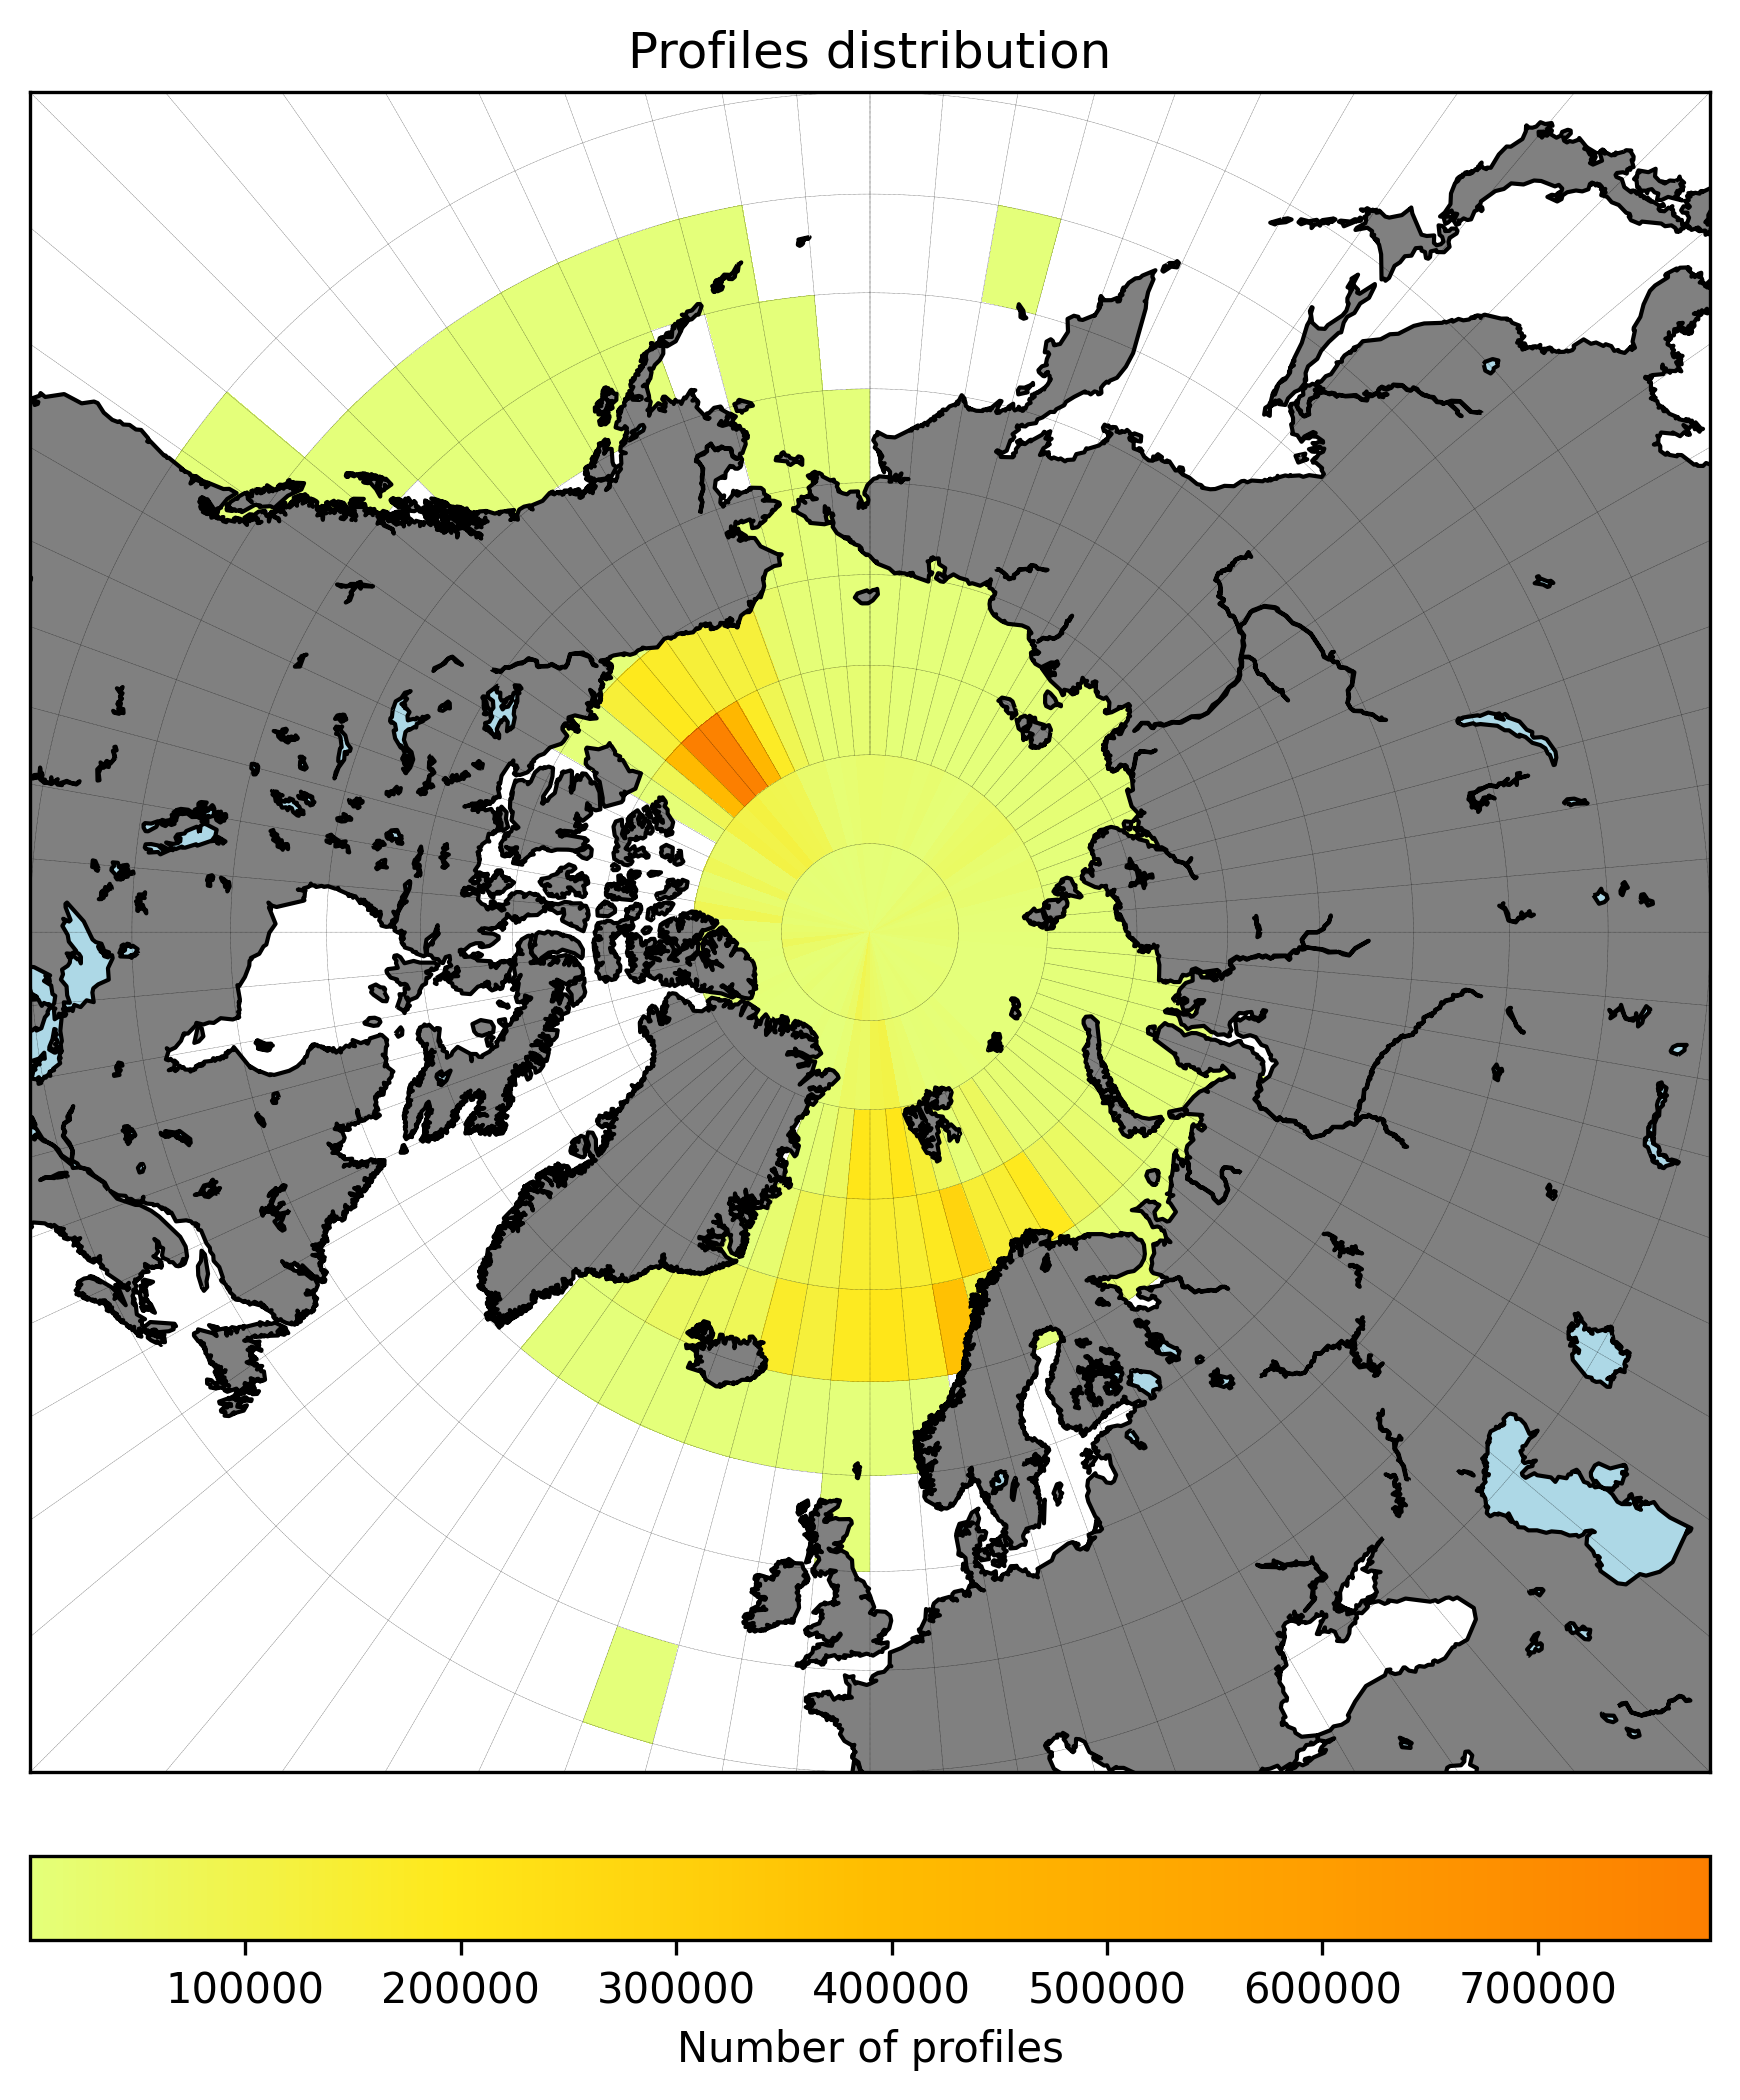

bin max=780010.0


In [16]:
plot_heatmap(sampled_df)